# Zadanie 3

In [1]:
# pip install torch torchvision scikit-learn matplotlib seaborn tqdm

import os, random, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18

from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
DATA_ROOT = Path('./data')
SAMPLES_PER_PARTITION = 5000

base_transform = T.Compose([
    T.ToTensor(),
])

mnist_train = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=base_transform)
mnist_test  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=base_transform)
print(f'Train: {len(mnist_train)}, Test: {len(mnist_test)}')

Train: 60000, Test: 10000


## Definicja ataków z różnymi parametrami

In [9]:
def attack_gaussian_noise(img: torch.Tensor, std: float = 0.15) -> torch.Tensor:
    return (img + torch.randn_like(img) * std).clamp(0, 1)


def attack_salt_pepper(img: torch.Tensor, prob: float = 0.10) -> torch.Tensor:
    out = img.clone()
    mask = torch.rand_like(img)
    out[mask < prob / 2]  = 0.0
    out[mask > 1 - prob / 2] = 1.0
    return out


def attack_geometric(img: torch.Tensor, magnitude: float = 6.0) -> torch.Tensor:
    transform = T.ElasticTransform(alpha=magnitude * 50, sigma=magnitude)
    return transform(img)


def attack_blending(img: torch.Tensor, alpha: float = 0.25) -> torch.Tensor:
    pattern = torch.rand_like(img)
    return ((1 - alpha) * img + alpha * pattern).clamp(0, 1)


def attack_trigger(img: torch.Tensor, trigger_size: int = 5) -> torch.Tensor:
    out = img.clone()
    H, W = img.shape[-2], img.shape[-1]
    x = random.randint(0, W - trigger_size)
    y = random.randint(0, H - trigger_size)
    out[:, y:y+trigger_size, x:x+trigger_size] = 1.0
    return out


ATTACKS = {
    'attack_a': attack_gaussian_noise,
    'attack_b': attack_salt_pepper,
    'attack_c': attack_geometric,
    'attack_d': attack_blending,
    'attack_e': attack_trigger,
    
    'attack_a_low': lambda x: attack_gaussian_noise(x, std=0.05),
    'attack_a_high': lambda x: attack_gaussian_noise(x, std=0.3),
    
    'attack_b_low': lambda x: attack_salt_pepper(x, prob=0.05),
    'attack_b_high': lambda x: attack_salt_pepper(x, prob=0.20),
    
    'attack_c_low': lambda x: attack_geometric(x, magnitude=3.0),
    # Fixed magnitude for max kernel size limitation in ElasticTransform on 28x28 images.
    # Sigma can be at most ~6.75 so the padding stays smaller than 28.
    'attack_c_high': lambda x: attack_geometric(x, magnitude=6.5),
    
    'attack_d_low': lambda x: attack_blending(x, alpha=0.1),
    'attack_d_high': lambda x: attack_blending(x, alpha=0.5),
    
    'attack_e_small': lambda x: attack_trigger(x, trigger_size=2),
    'attack_e_large': lambda x: attack_trigger(x, trigger_size=10),
}

In [4]:
class TransformSubset(Dataset):
    def __init__(self, subset, attack_fn=None, is_poisoned=0):
        self.subset = subset
        self.attack_fn = attack_fn
        self.is_poisoned = is_poisoned

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.attack_fn:
            img = self.attack_fn(img)
        return img, label, self.is_poisoned

def create_joined_poisoned_dataset(base_dataset, attack_fn):
    
    clean_subset = TransformSubset(base_dataset, attack_fn=None, is_poisoned=0)
    poison_subset = TransformSubset(base_dataset, attack_fn=attack_fn, is_poisoned=1)
    
    # Join the clean and poisoned data
    return ConcatDataset([clean_subset, poison_subset])


## Autoenkoder

In [5]:
import pytorch_lightning as pl

class LitAutoEncoder(pl.LightningModule):
    def __init__(self, input_dim=28*28, hidden_dim=128, latent_dim=32):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Images are 0-1 scaled
        )
        
        self.criterion = nn.MSELoss()

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        
        z = self.encoder(x_flat)
        x_reconstructed = self.decoder(z)
        
        return x_reconstructed.view(x.shape)

    def training_step(self, batch, batch_idx):
        # batch contains: img, label, is_poisoned
        x = batch[0]
        x_hat = self(x)
        
        loss = self.criterion(x_hat, x)
        self.log('train_loss', loss, prog_bar=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        x = batch[0]
        x_hat = self(x)
        
        loss = self.criterion(x_hat, x)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

## Trening

In [6]:
# Create dataset for this attack
from pytorch_lightning import Trainer


clean_subset = TransformSubset(mnist_train, attack_fn=None, is_poisoned=0)

# Split train dataset into train and validation (80/20 split)
train_size = int(0.8 * len(clean_subset))
val_size = len(clean_subset) - train_size
train_split, val_split = torch.utils.data.random_split(clean_subset, [train_size, val_size])

# Initialize DataLoaders
train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

# Initialize Model and Trainer
model = LitAutoEncoder()
trainer = Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    enable_model_summary=False,
)

# Start training
trainer.fit(model, train_loader, val_loader)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


## Wyniki

Clean Mean MSE: 0.0076 +/- 0.0045


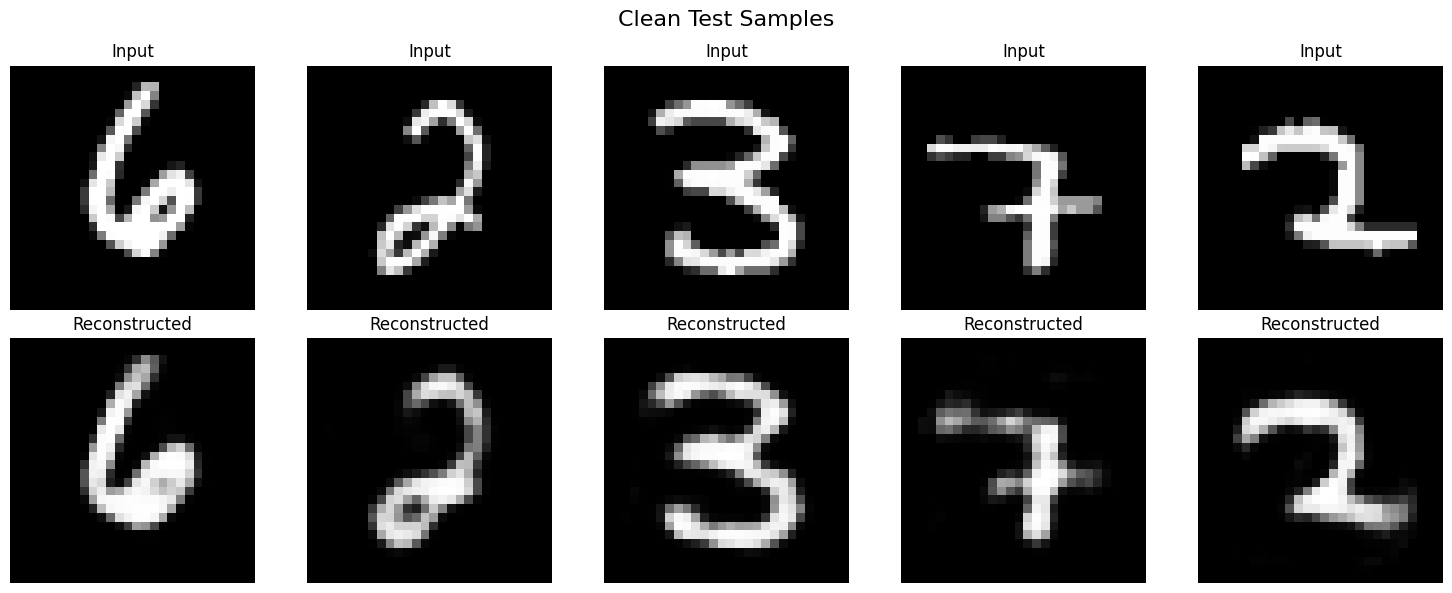

In [7]:
# Create Test DataLoaders for Clean test set
clean_test = TransformSubset(mnist_test, attack_fn=None, is_poisoned=0)
clean_test_loader = DataLoader(clean_test, batch_size=256, shuffle=False)

def evaluate_reconstruction(model, loader):
    model.eval()
    model.to(DEVICE)
    losses = []
    criterion = nn.MSELoss(reduction='none')
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            x_hat = model(x)
            
            # Compute MSE per image
            loss = criterion(x_hat, x)
            loss_per_image = loss.view(loss.size(0), -1).mean(dim=1)
            losses.extend(loss_per_image.cpu().numpy())
    return np.array(losses)

def show_reconstructions(model, dataset, title=""):
    model.eval()
    model.to(DEVICE)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=16)
    
    indices = np.random.choice(len(dataset), 5, replace=False)
    
    for i, idx in enumerate(indices):
        x = dataset[idx][0].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            x_hat = model(x)
        
        # Original (or Attacked)
        axes[0, i].imshow(x.squeeze().cpu().numpy(), cmap='gray')
        axes[0, i].set_title("Input")
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(x_hat.squeeze().cpu().numpy(), cmap='gray')
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

clean_losses = evaluate_reconstruction(model, clean_test_loader)
print(f"Clean Mean MSE: {clean_losses.mean():.4f} +/- {clean_losses.std():.4f}")

show_reconstructions(model, clean_test, title="Clean Test Samples")


--- Evaluating attack_a ---
attack_a Mean MSE: 0.0234 +/- 0.0046
ROC AUC for detecting attack_a: 0.9876


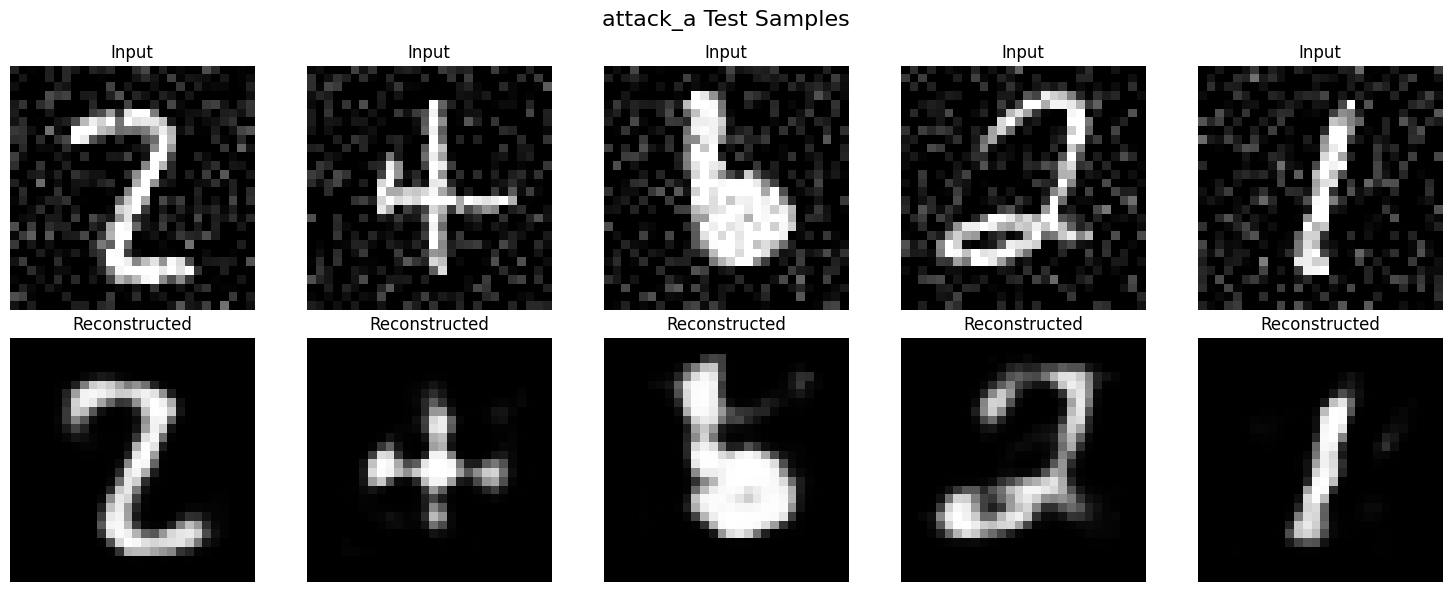


--- Evaluating attack_b ---
attack_b Mean MSE: 0.0597 +/- 0.0096
ROC AUC for detecting attack_b: 1.0000


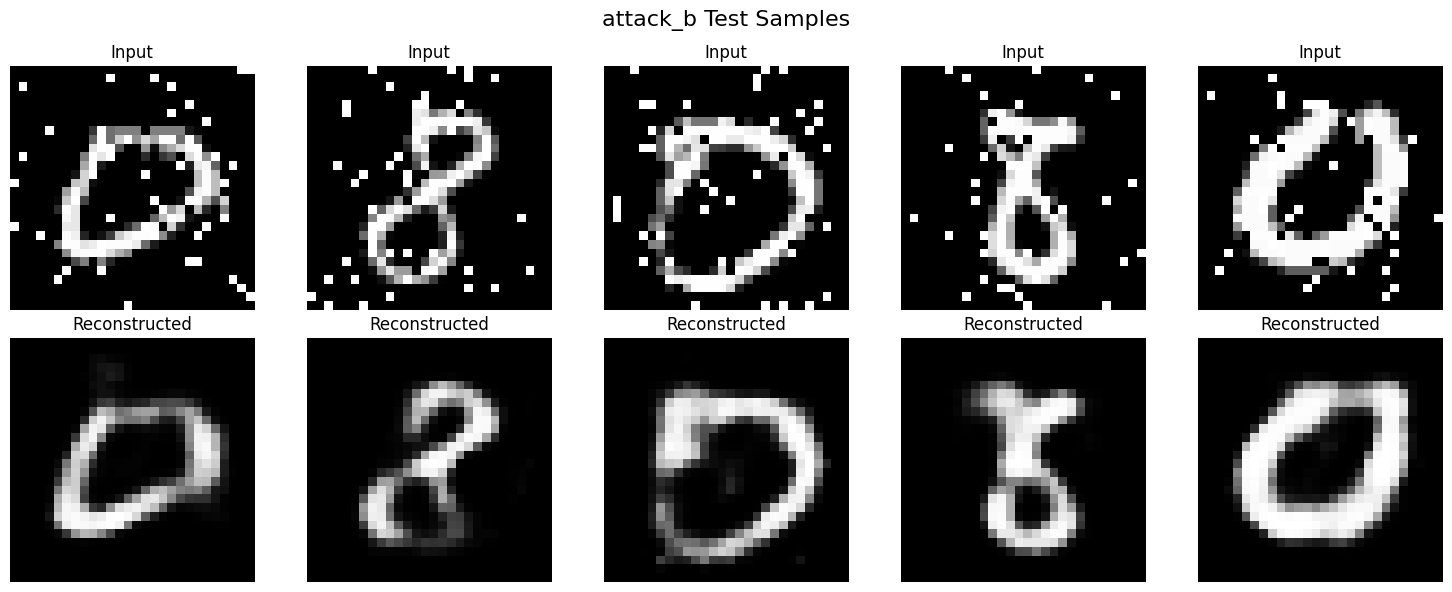


--- Evaluating attack_c ---
attack_c Mean MSE: 0.0496 +/- 0.0422
ROC AUC for detecting attack_c: 0.9424


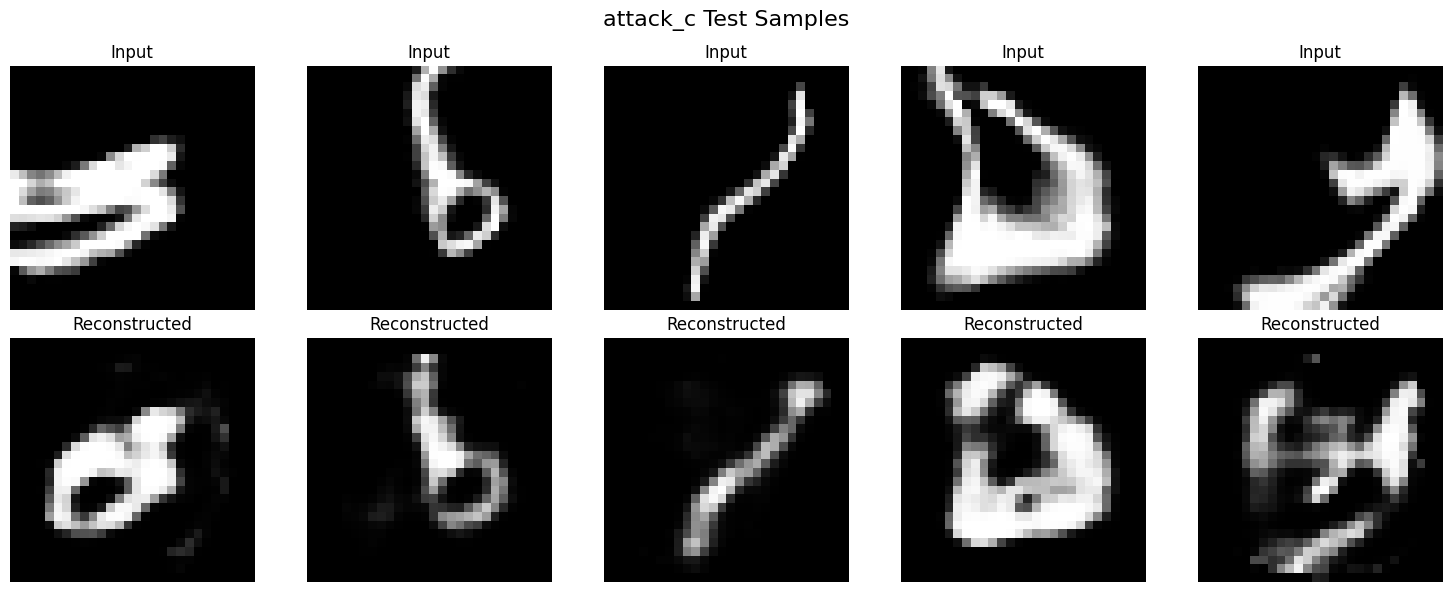


--- Evaluating attack_d ---
attack_d Mean MSE: 0.0347 +/- 0.0050
ROC AUC for detecting attack_d: 0.9993


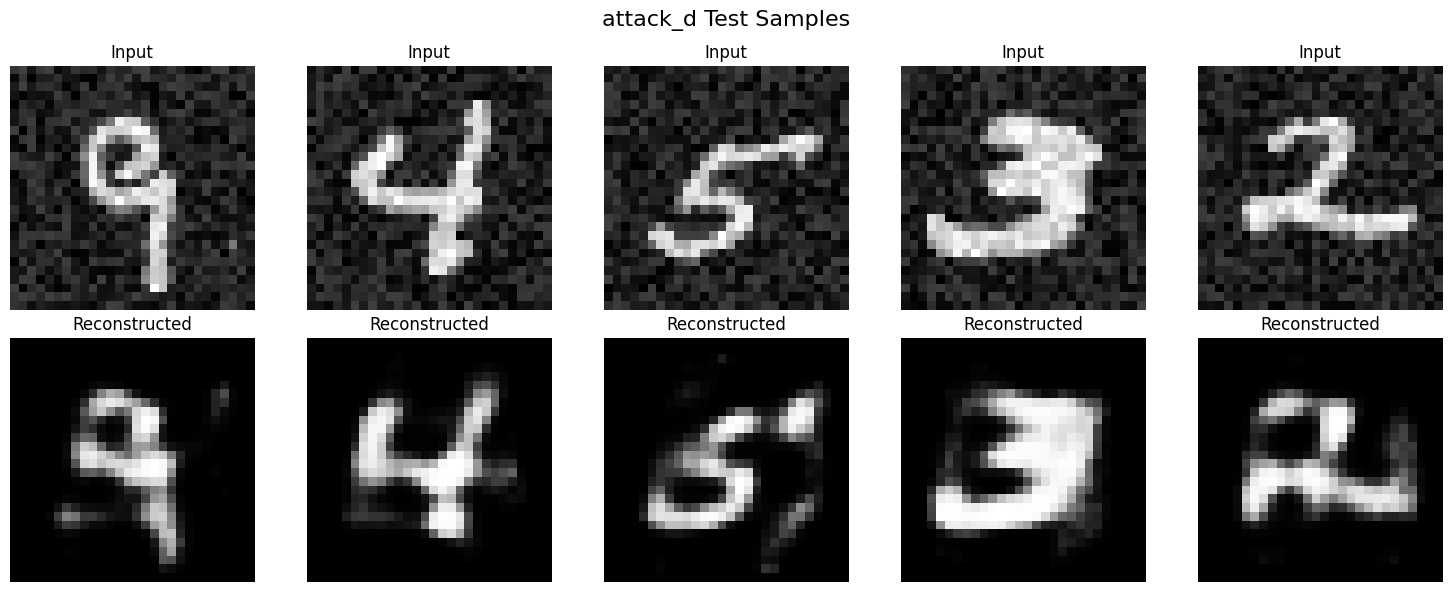


--- Evaluating attack_e ---
attack_e Mean MSE: 0.0277 +/- 0.0154
ROC AUC for detecting attack_e: 0.9190


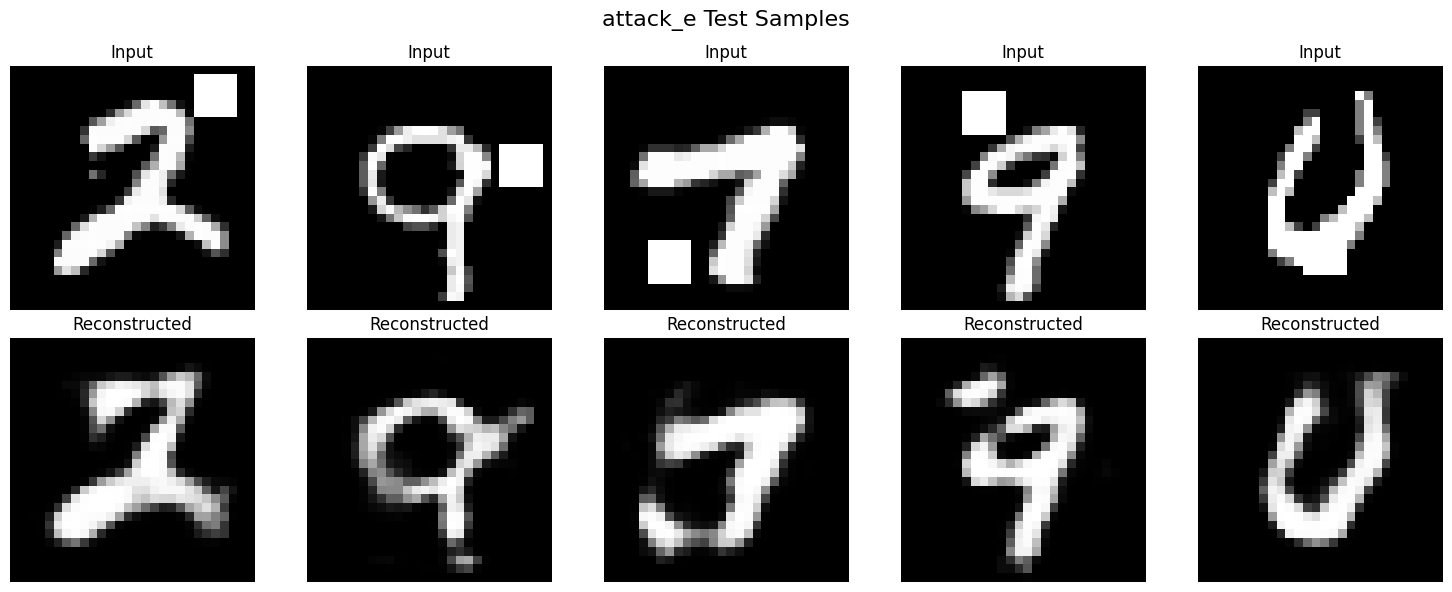


--- Evaluating attack_a_low ---
attack_a_low Mean MSE: 0.0095 +/- 0.0043
ROC AUC for detecting attack_a_low: 0.6378


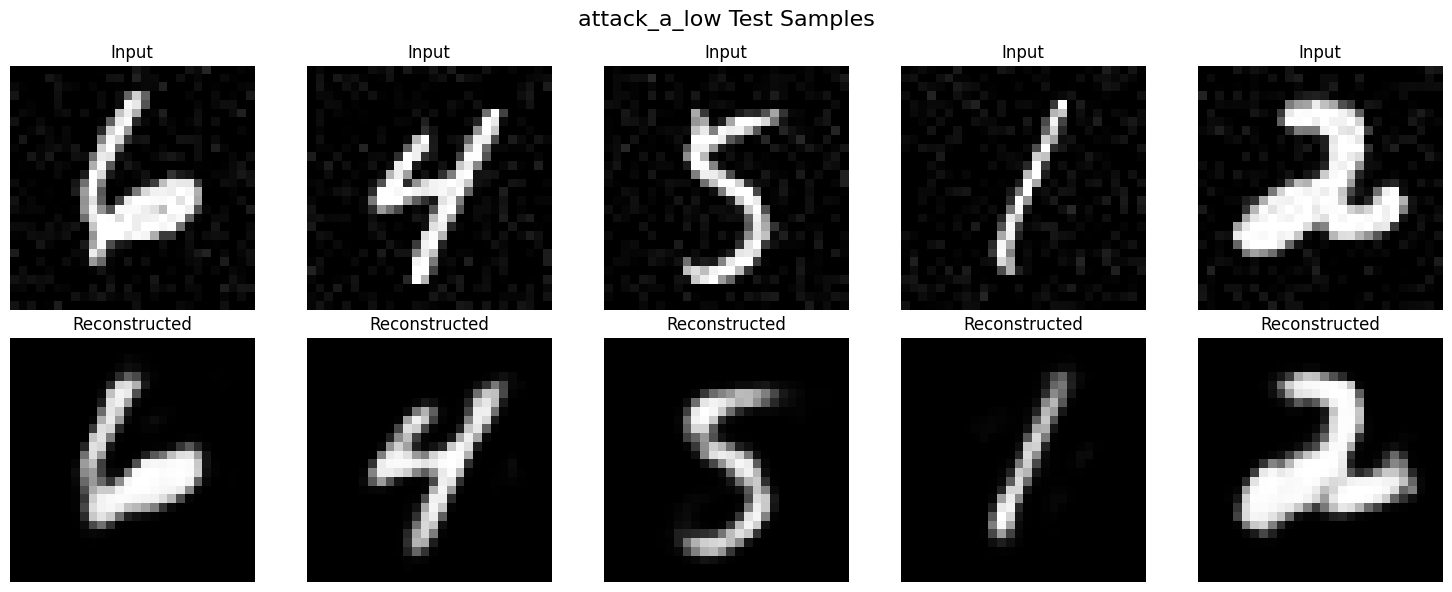


--- Evaluating attack_a_high ---
attack_a_high Mean MSE: 0.0618 +/- 0.0070
ROC AUC for detecting attack_a_high: 1.0000


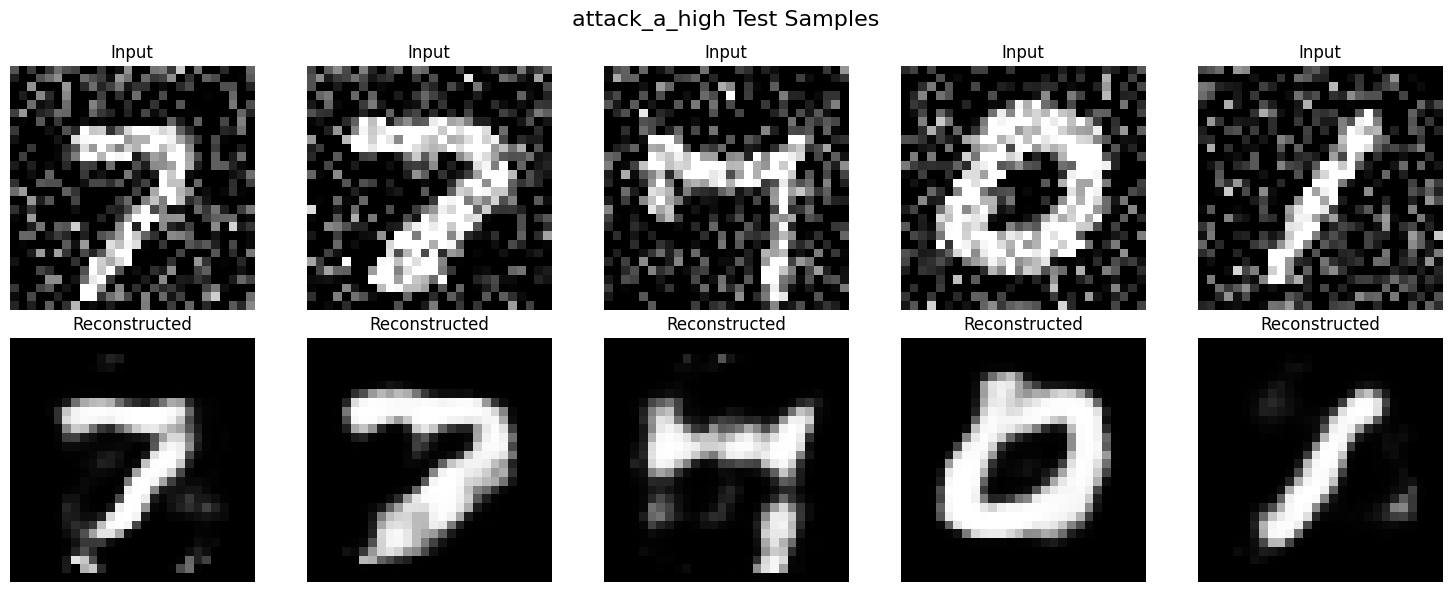


--- Evaluating attack_b_low ---
attack_b_low Mean MSE: 0.0336 +/- 0.0074
ROC AUC for detecting attack_b_low: 0.9979


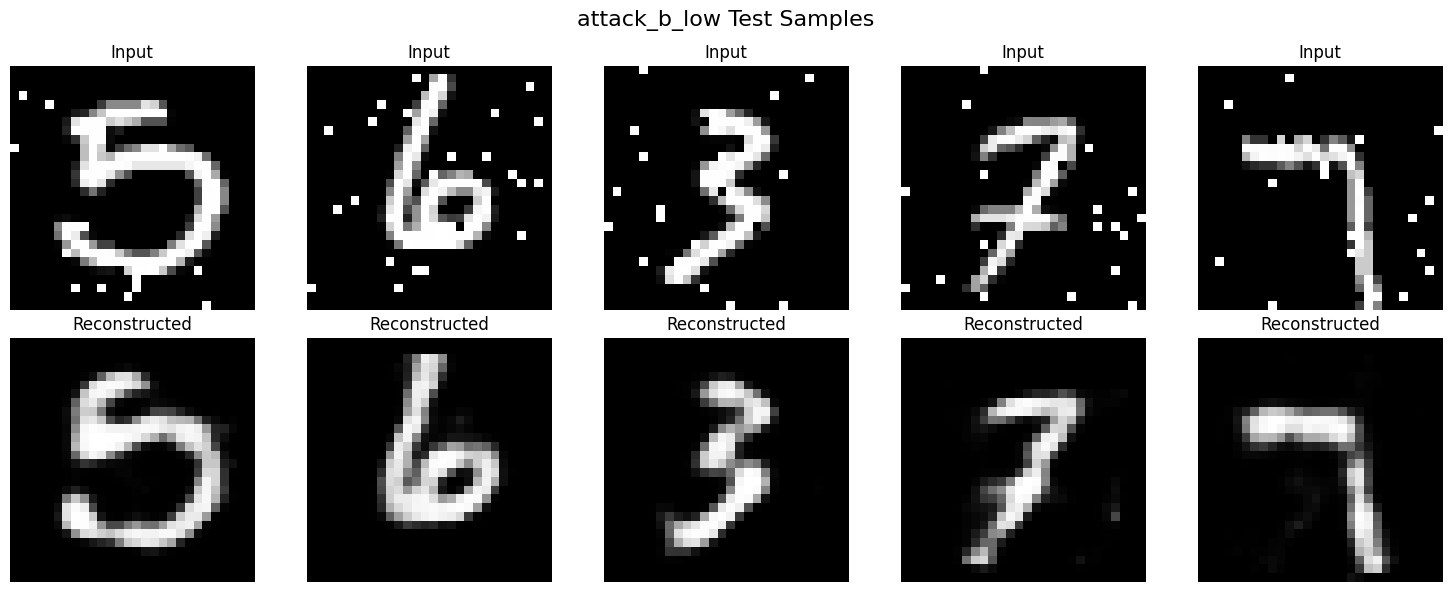


--- Evaluating attack_b_high ---
attack_b_high Mean MSE: 0.1111 +/- 0.0126
ROC AUC for detecting attack_b_high: 1.0000


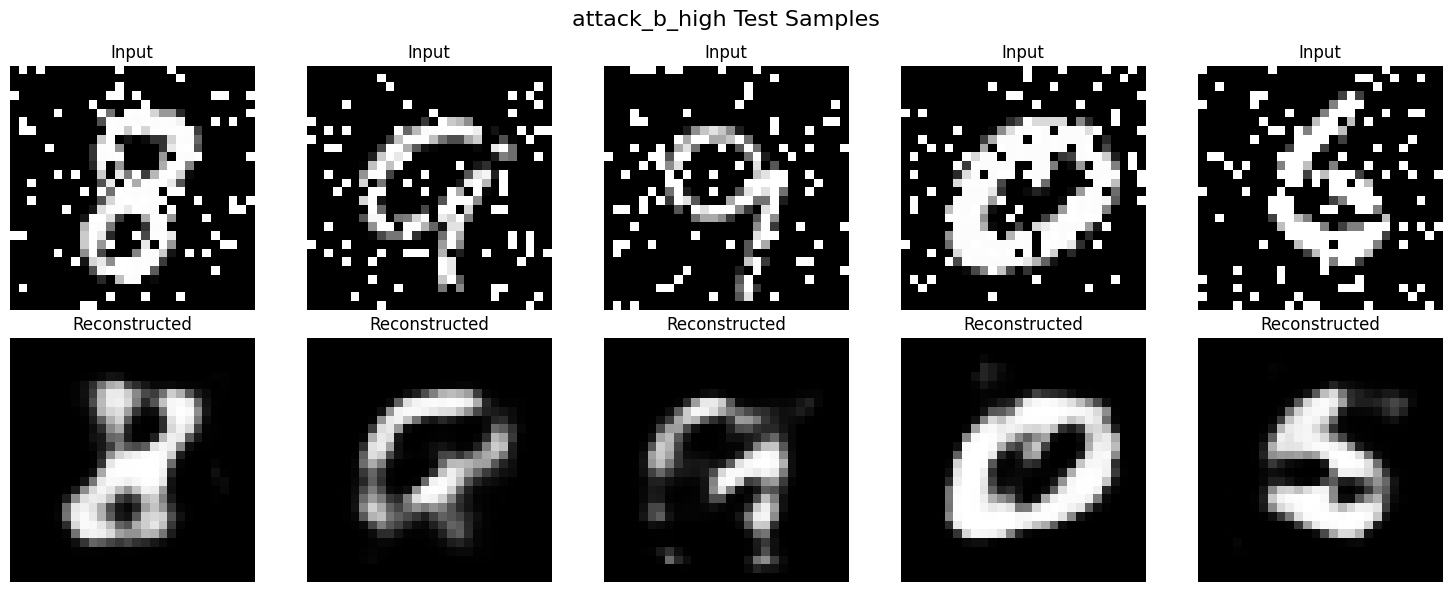


--- Evaluating attack_c_low ---
attack_c_low Mean MSE: 0.0517 +/- 0.0325
ROC AUC for detecting attack_c_low: 0.9802


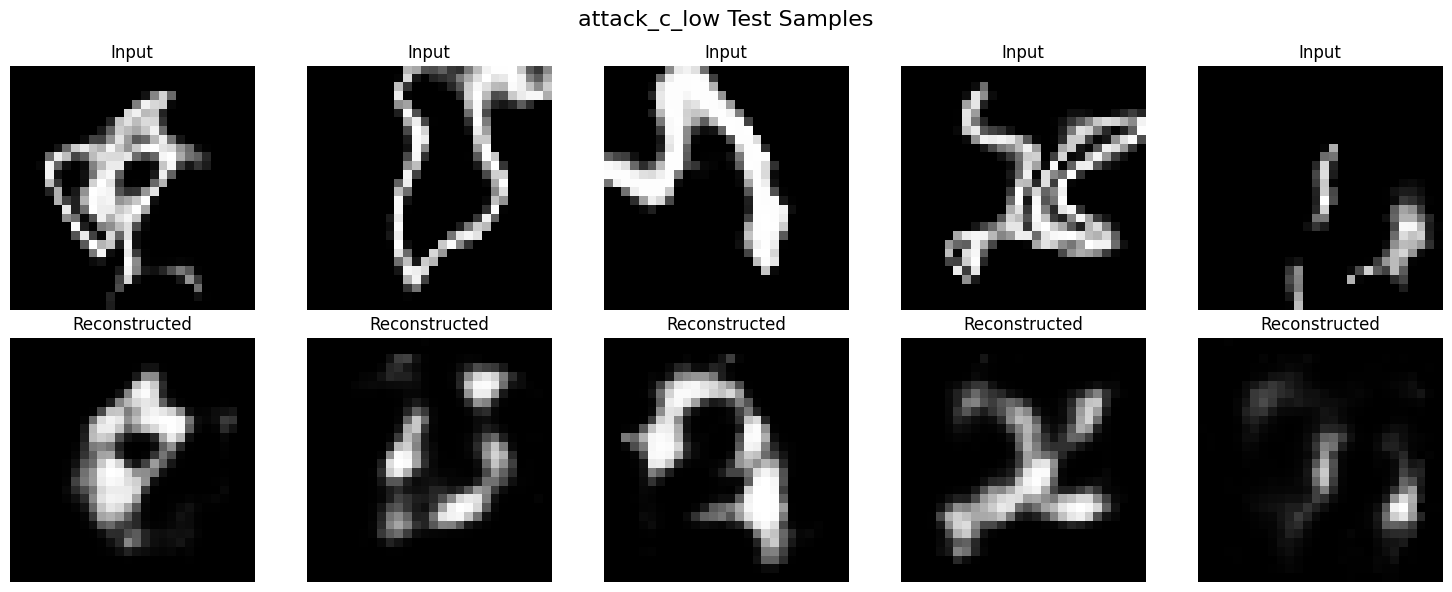


--- Evaluating attack_c_high ---
attack_c_high Mean MSE: 0.0503 +/- 0.0462
ROC AUC for detecting attack_c_high: 0.9405


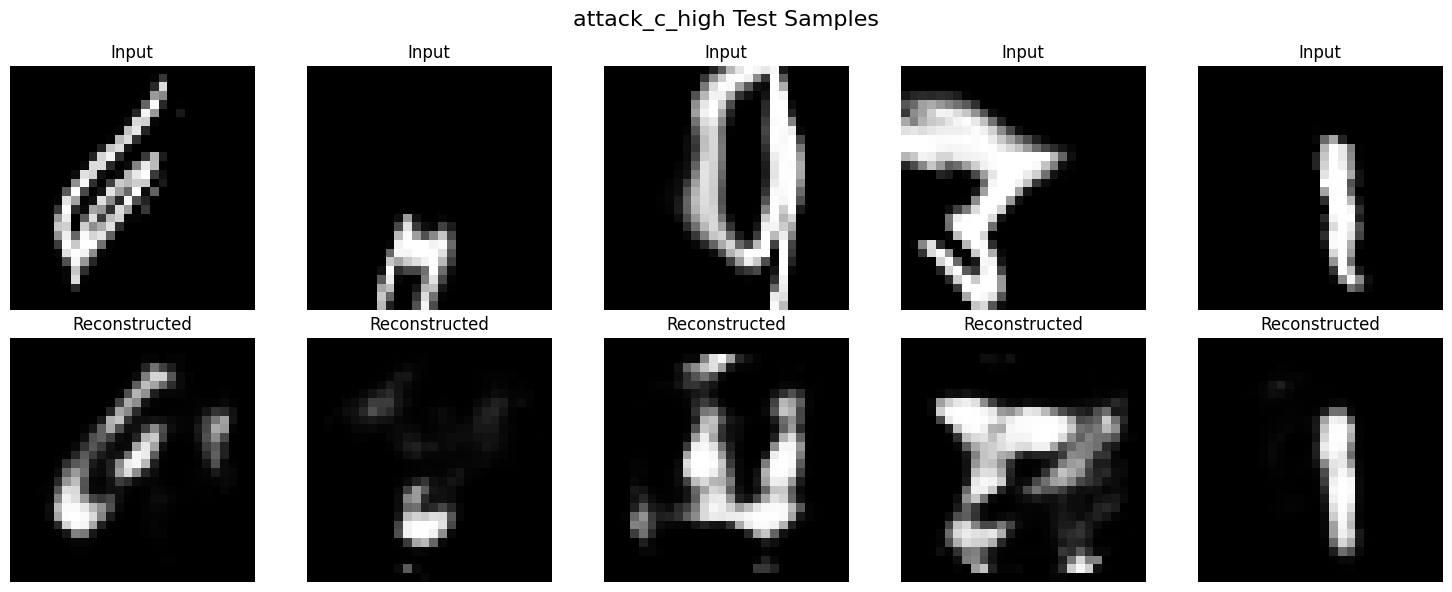


--- Evaluating attack_d_low ---
attack_d_low Mean MSE: 0.0131 +/- 0.0039
ROC AUC for detecting attack_d_low: 0.8420


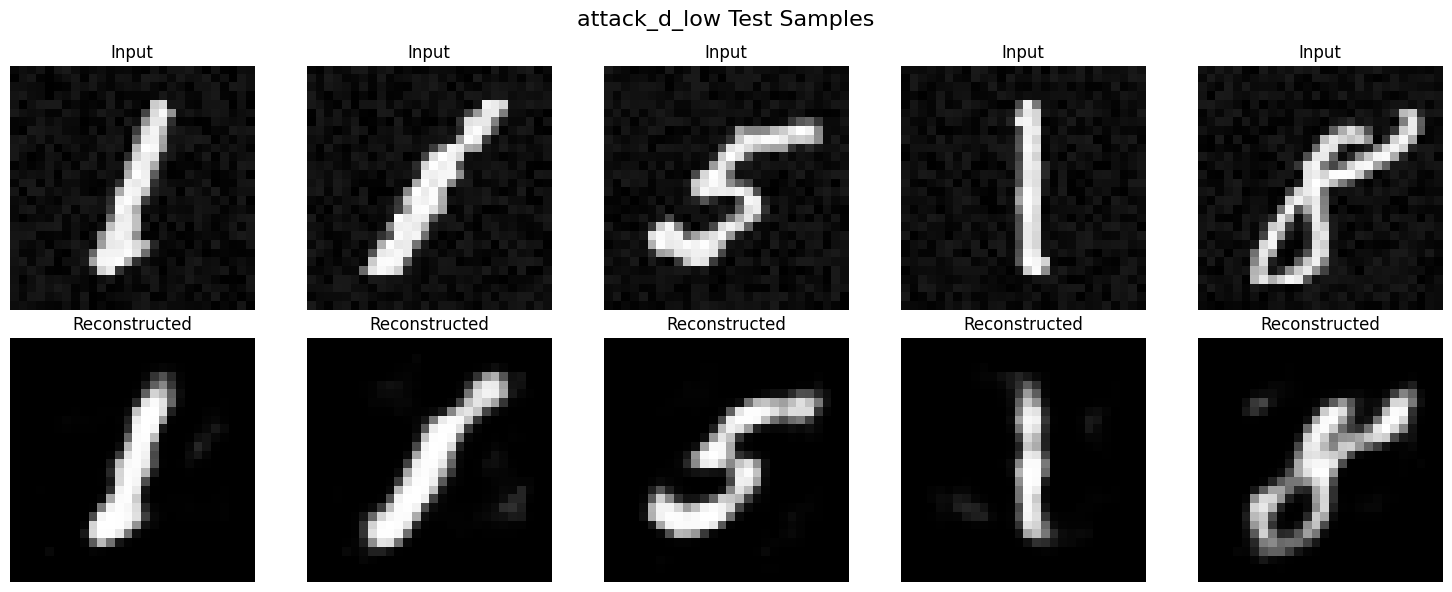


--- Evaluating attack_d_high ---
attack_d_high Mean MSE: 0.0896 +/- 0.0064
ROC AUC for detecting attack_d_high: 1.0000


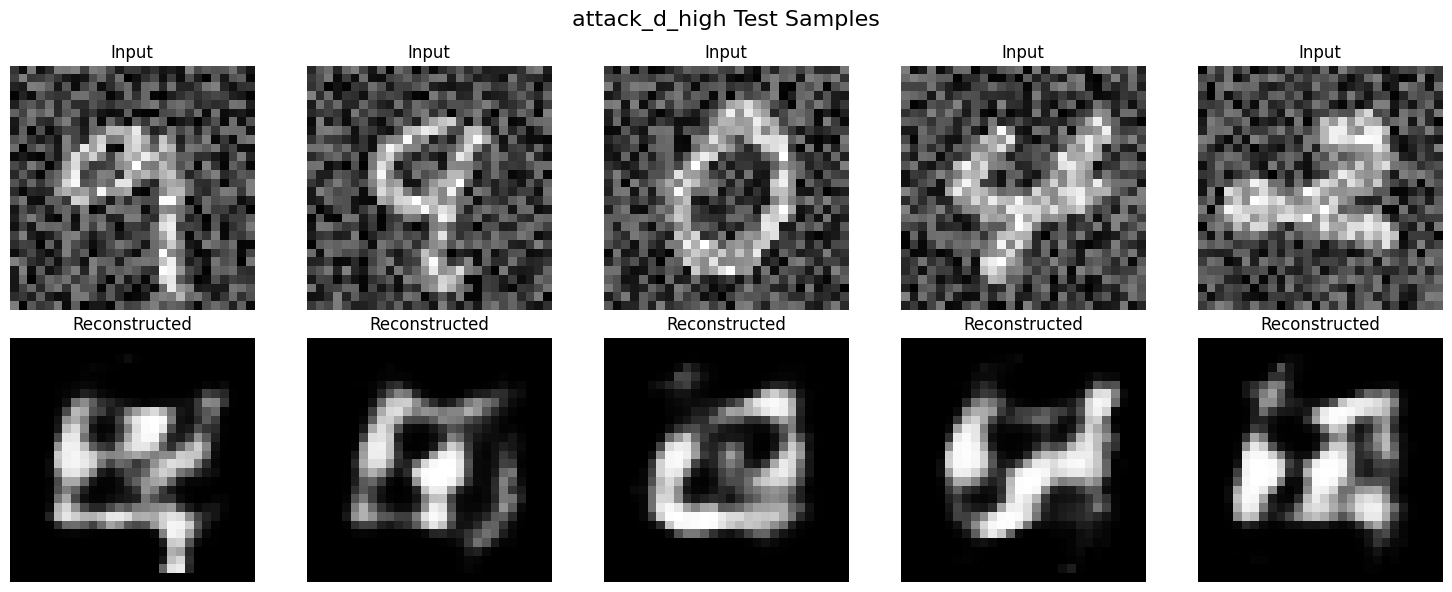


--- Evaluating attack_e_small ---
attack_e_small Mean MSE: 0.0125 +/- 0.0052
ROC AUC for detecting attack_e_small: 0.7812


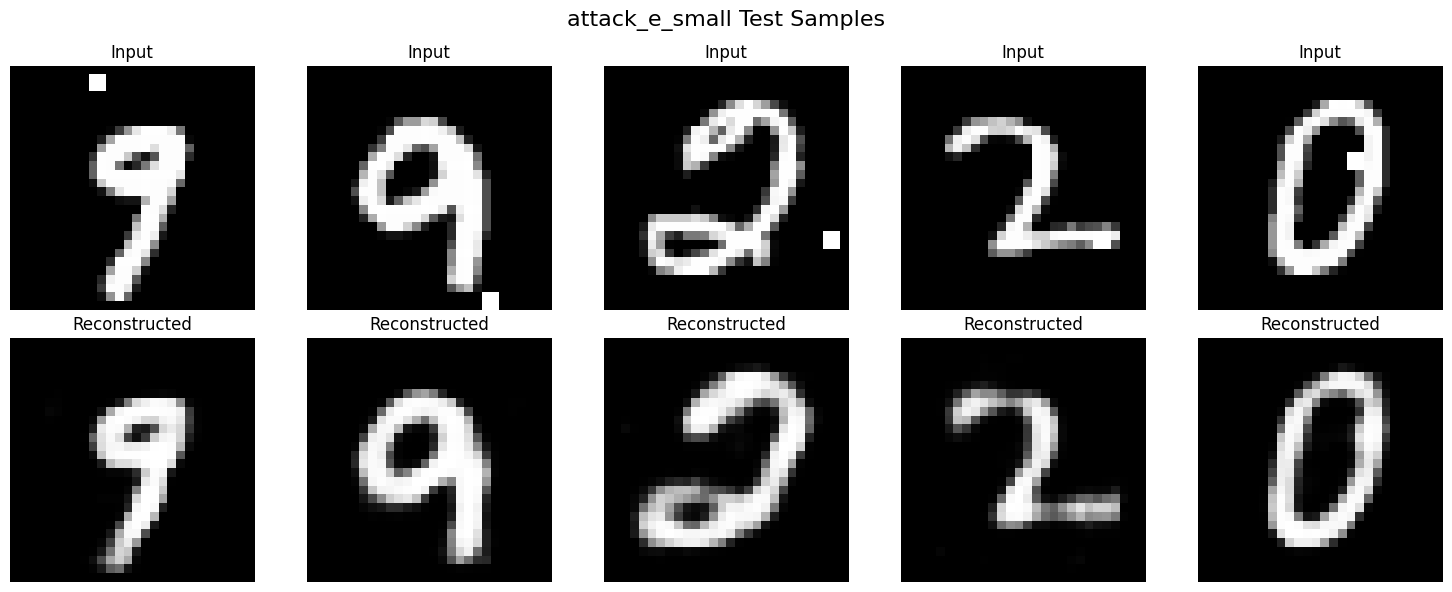


--- Evaluating attack_e_large ---
attack_e_large Mean MSE: 0.0687 +/- 0.0368
ROC AUC for detecting attack_e_large: 0.9842


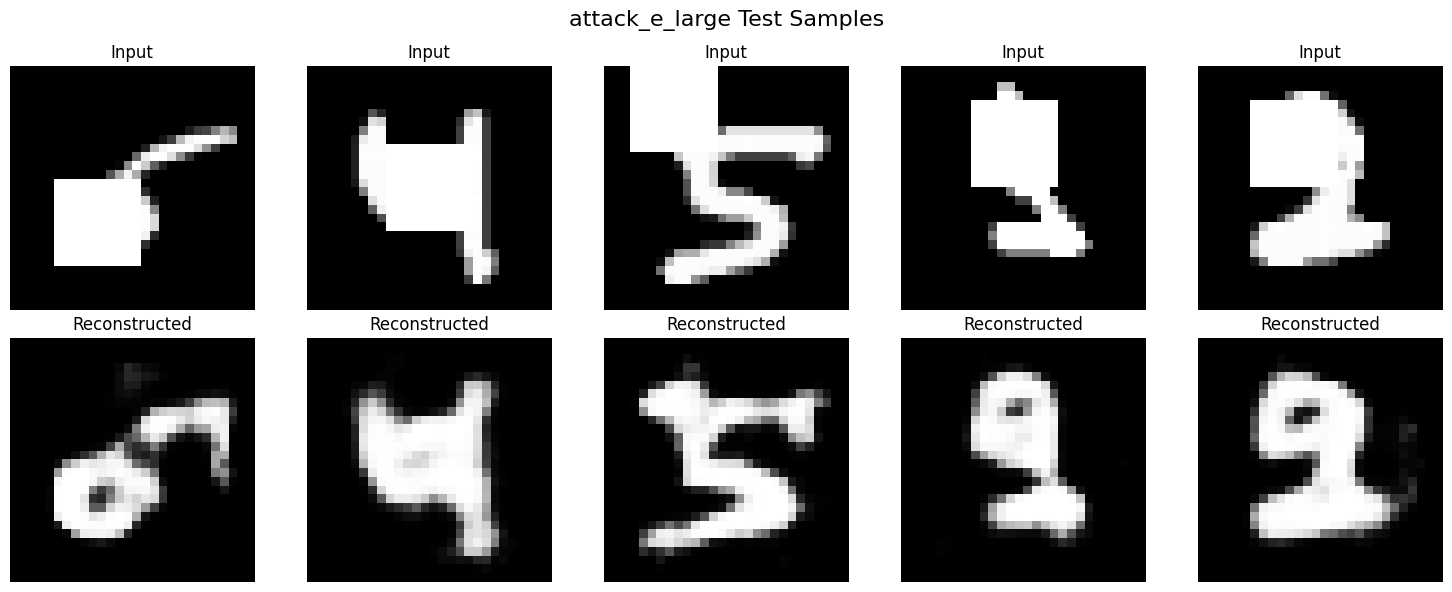


=== Summary of All Attacks ===


,Attack,Mean MSE,Std MSE,ROC AUC
6,attack_a_high,0.061762,0.007007,1.000000
12,attack_d_high,0.089623,0.006386,1.000000
8,attack_b_high,0.111127,0.012636,1.000000
1,attack_b,0.059700,0.009580,0.999998
3,attack_d,0.034678,0.004959,0.999323
7,attack_b_low,0.033582,0.007436,0.997902
0,attack_a,0.023363,0.004608,0.987593
14,attack_e_large,0.068716,0.036753,0.984179
9,attack_c_low,0.051693,0.032526,0.980211
2,attack_c,0.049565,0.042212,0.942416


In [10]:
import pandas as pd
from IPython.display import display

results = []

for attack_name, attack_fn in ATTACKS.items():
    print(f"\n--- Evaluating {attack_name} ---")
    
    # Create test subset and loader for the current attack
    attack_test = TransformSubset(mnist_test, attack_fn=attack_fn, is_poisoned=1)
    attack_test_loader = DataLoader(attack_test, batch_size=256, shuffle=False)
    
    # Evaluate reconstruction
    attack_losses = evaluate_reconstruction(model, attack_test_loader)
    
    mean_mse = attack_losses.mean()
    std_mse = attack_losses.std()
    print(f"{attack_name} Mean MSE: {mean_mse:.4f} +/- {std_mse:.4f}")
    
    # Calculate ROC AUC
    y_true = np.concatenate([np.zeros(len(clean_losses)), np.ones(len(attack_losses))])
    y_scores = np.concatenate([clean_losses, attack_losses])
    
    auc = roc_auc_score(y_true, y_scores)
    print(f"ROC AUC for detecting {attack_name}: {auc:.4f}")
    
    # Store results
    results.append({
        'Attack': attack_name,
        'Mean MSE': mean_mse,
        'Std MSE': std_mse,
        'ROC AUC': auc
    })
    
    # Visualize examples
    show_reconstructions(model, attack_test, title=f"{attack_name} Test Samples")

# Compile all results into a DataFrame
print("\n=== Summary of All Attacks ===")
results_df = pd.DataFrame(results)
display(results_df.sort_values('ROC AUC', ascending=False))

# Zadanie 4

In [11]:
class LitAnomalyClassifier(pl.LightningModule):
    def __init__(self, encoder, fc_in=32, fc_hidden=64, dropout_rate1=0.2, dropout_rate2=0.1):
        super().__init__()
        
        # Use the encoder (e.g. from the trained LitAutoEncoder)
        self.encoder = encoder
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_in, fc_hidden),
            nn.GELU(),
            nn.Dropout(dropout_rate1),
            nn.Linear(fc_hidden, max(fc_hidden // 2, 16)),
            nn.GELU(),
            nn.Dropout(dropout_rate2),
            nn.Linear(max(fc_hidden // 2, 16), 1), 
        )
        
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        
        # Extract features
        z = self.encoder(x_flat)
        
        # Predict anomaly logic (0 for clean, 1 for poisoned)
        logits = self.classifier(z)
        return logits.view(-1)

    def training_step(self, batch, batch_idx):
        x = batch[0]
        is_poisoned = batch[2].float()
        
        logits = self(x)
        loss = self.criterion(logits, is_poisoned)
        self.log('train_classifier_loss', loss, prog_bar=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        x = batch[0]
        is_poisoned = batch[2].float()
        
        logits = self(x)
        loss = self.criterion(logits, is_poisoned)
        self.log('val_classifier_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

In [ ]:
models = {}

os.makedirs('saved_models', exist_ok=True)

for attack_name, attack_fn in ATTACKS.items():
    print(f"Training model for {attack_name}")
    
    # Create dataset for this attack
    poisoned_train_ds_attack = create_joined_poisoned_dataset(mnist_train, attack_fn)
    
    # Split train dataset into train and validation (80/20 split)
    train_size = int(0.8 * len(poisoned_train_ds_attack))
    val_size = len(poisoned_train_ds_attack) - train_size
    train_split, val_split = torch.utils.data.random_split(poisoned_train_ds_attack, [train_size, val_size])

    # Initialize DataLoaders
    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    # Initialize Model and Trainer
    model = LitAnomalyClassifier(encoder=model.encoder)
    trainer = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    # Start training
    trainer.fit(model, train_loader, val_loader)
    
    # Save the model
    model_path = os.path.join('saved_models', f"model_{attack_name}.ckpt")
    trainer.save_checkpoint(model_path)
    
    models[attack_name] = model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

...

Training model for attack_c_low


`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Training model for attack_c_high


In [ ]:
import seaborn as sns

fig, axes = plt.subplots(len(ATTACKS), len(ATTACKS), figsize=(4 * len(ATTACKS), 4 * len(ATTACKS)))

for i, (model_name, model) in enumerate(models.items()):
    model.eval()
    for j, (attack_name, attack_fn) in enumerate(ATTACKS.items()):
        # Create test dataset with the specific attack
        test_ds = create_joined_poisoned_dataset(mnist_test, attack_fn)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds_attack = []
        all_poisoned_attack = []
        
        with torch.no_grad():
            for imgs, labels, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds_attack.extend(preds.numpy())
                all_poisoned_attack.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned_attack, all_preds_attack)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        ax.set_title(f"Mod: {model_name} | Att: {attack_name}")
        if i == len(ATTACKS) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
import os

class RandomAttackSubset(Dataset):
    def __init__(self, subset, attack_fns, is_poisoned=0):
        self.subset = subset
        self.attack_fns = attack_fns
        self.is_poisoned = is_poisoned

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.attack_fns and self.is_poisoned == 1:
            attack_fn = random.choice(self.attack_fns)
            img = attack_fn(img)
        return img, label, self.is_poisoned

# 50% clean, 50% poisoned (from multiple attacks)
def create_mixed_poisoned_dataset(base_dataset, attack_fns):
    clean_subset = TransformSubset(base_dataset, attack_fn=None, is_poisoned=0)
    poison_subset = RandomAttackSubset(base_dataset, attack_fns=attack_fns, is_poisoned=1)
    return ConcatDataset([clean_subset, poison_subset])

mixed_models = {}
os.makedirs('saved_models', exist_ok=True)

# Train a model for each leave-one-out combination of attacks
for held_out_attack_name in ATTACKS.keys():
    train_attack_names = [k for k in ATTACKS.keys() if k != held_out_attack_name]
    
    print(f"\n--- Training model holding out (unseen): {held_out_attack_name} ---")
    
    train_attack_fns = [ATTACKS[k] for k in train_attack_names]
    mixed_train_ds = create_mixed_poisoned_dataset(mnist_train, train_attack_fns)

    train_size = int(0.8 * len(mixed_train_ds))
    val_size = len(mixed_train_ds) - train_size
    train_split, val_split = torch.utils.data.random_split(mixed_train_ds, [train_size, val_size])

    train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

    mixed_model = PoisonClassifier(lr=1e-3)
    trainer_mixed = Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )

    trainer_mixed.fit(mixed_model, train_loader, val_loader)
    
    mixed_model_path = os.path.join('saved_models', f"model_mixed_no_{held_out_attack_name}.ckpt")
    trainer_mixed.save_checkpoint(mixed_model_path)
    
    mixed_models[held_out_attack_name] = mixed_model


# Plotting evaluation grid
fig, axes = plt.subplots(len(mixed_models), len(ATTACKS), figsize=(4 * len(ATTACKS), 4 * len(mixed_models)))

for i, (held_out_name, model) in enumerate(mixed_models.items()):
    model.eval()
    for j, (test_attack_name, test_attack_fn) in enumerate(ATTACKS.items()):
        # Create test dataset with the specific attack
        test_ds = create_joined_poisoned_dataset(mnist_test, test_attack_fn)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
        
        all_preds_attack = []
        all_poisoned_attack = []
        
        with torch.no_grad():
            for imgs, labels, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                logits = model(imgs)
                preds = (torch.sigmoid(logits) > 0.5).long().cpu()
                
                all_preds_attack.extend(preds.numpy())
                all_poisoned_attack.extend(is_poisoned.numpy())
                
        cm = confusion_matrix(all_poisoned_attack, all_preds_attack)
        ax = axes[i, j]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Clean', 'Poisoned'], 
                    yticklabels=['Clean', 'Poisoned'])
        
        title = f"Unseen: {held_out_name}\nTest: {test_attack_name}"
        ax.set_title(title)
        
        if i == len(mixed_models) - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("True")

plt.tight_layout()
plt.show()